In [237]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.preprocessing import MinMaxScaler


In [238]:
import pandas as pd
import numpy as np

In [239]:
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("val.csv")
test_df = pd.read_csv("test.csv")
train_df = train_df.set_index("Datetime")
val_df = val_df.set_index("Datetime")
test_df = test_df.set_index("Datetime")
train_df.head()

,Global_active_power_mean,Global_active_power_max,Global_active_power_min,Global_active_power_std,Voltage_mean,Voltage_max,Voltage_min,Voltage_std,Global_intensity_mean,Global_intensity_max,...,is_weekend,lag_1,lag_24,lag_168,roll_mean_6h,roll_std_6h,roll_mean_24h,roll_std_24h,roll_mean_168h,roll_std_168h
Datetime,,,,,,,,,,,,,,,,,,,,,
2006-12-23 17:00:00,5.429683,7.164,2.984,1.192589,233.644167,236.25,231.17,1.311882,23.360000,30.4,...,1,4.326733,1.496800,4.188278,3.607728,0.539234,2.931298,0.983724,1.762654,1.143968
2006-12-23 18:00:00,3.879400,5.270,1.666,0.886704,238.000500,240.59,235.57,1.222337,16.363333,22.4,...,1,5.429683,2.686967,3.598283,3.986175,0.861707,3.095168,1.059062,1.770044,1.163571
2006-12-23 19:00:00,4.117833,5.392,2.036,0.831345,238.729333,242.24,235.69,1.477832,17.300000,22.8,...,1,3.879400,3.938167,3.400233,4.144608,0.700778,3.144853,1.067020,1.771717,1.166414
2006-12-23 20:00:00,4.181400,6.230,2.366,0.850218,238.518833,242.02,236.01,1.235284,17.596667,26.2,...,1,4.117833,3.536067,3.268567,4.263197,0.604431,3.152339,1.073439,1.775988,1.173705
2006-12-23 21:00:00,3.288433,5.352,1.390,1.035213,238.594667,241.65,234.89,1.450798,13.893333,22.8,...,1,4.181400,4.451267,3.056467,4.333769,0.556460,3.179228,1.091401,1.781422,1.182734


In [240]:
lag_roll_cols = [
    "lag_1", "lag_24", "roll_mean_24h", "roll_std_24h",
]

corr_lr = train_df[lag_roll_cols].corr()
print(corr_lr)



                  lag_1    lag_24  roll_mean_24h  roll_std_24h
lag_1          1.000000  0.375464       0.423097      0.379782
lag_24         0.375464  1.000000       0.425912      0.350772
roll_mean_24h  0.423097  0.425912       1.000000      0.810499
roll_std_24h   0.379782  0.350772       0.810499      1.000000


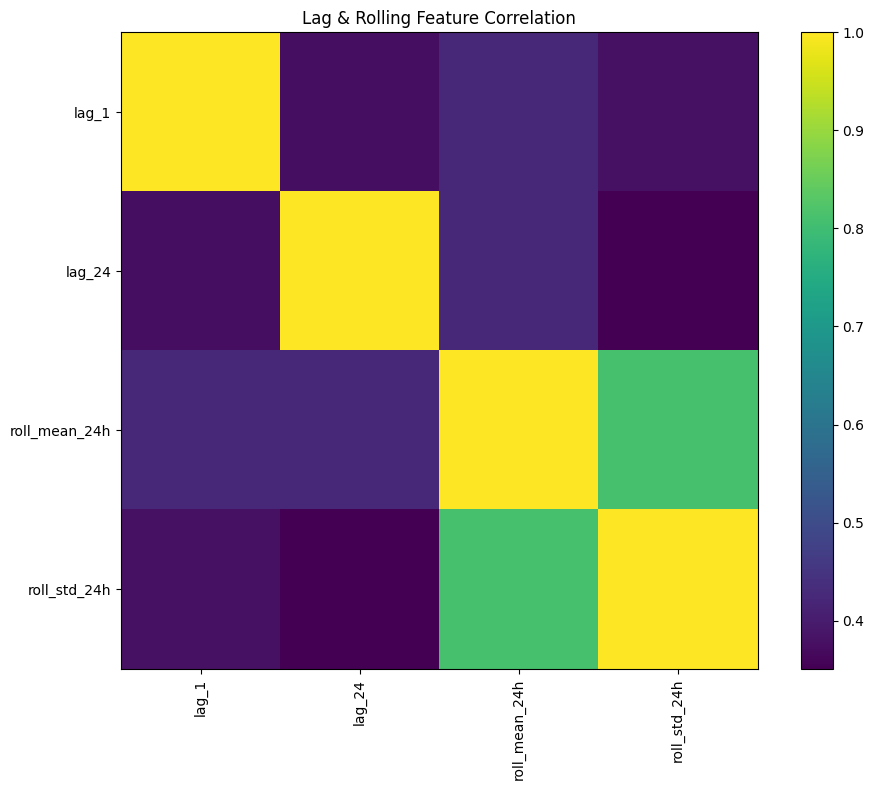

In [241]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(corr_lr)
plt.colorbar()

plt.xticks(range(len(lag_roll_cols)), lag_roll_cols, rotation=90)
plt.yticks(range(len(lag_roll_cols)), lag_roll_cols)

plt.title("Lag & Rolling Feature Correlation")
plt.tight_layout()
plt.show()


In [242]:
target_corr = train_df.corr()["Global_active_power_mean"].sort_values(ascending=False)

# print(target_corr.head(15))
# print(target_corr.tail(15))
print(target_corr)


Global_active_power_mean    1.000000
Global_intensity_mean       0.997147
Global_active_power_max     0.865033
Global_intensity_max        0.859348
Global_intensity_min        0.851831
Global_active_power_min     0.848939
lag_1                       0.719976
Sub_metering_3_mean         0.686580
Global_intensity_std        0.679953
Global_active_power_std     0.675858
Sub_metering_3_min          0.540389
Sub_metering_3_max          0.525692
Sub_metering_1_mean         0.497604
Sub_metering_1_std          0.490915
Voltage_std                 0.487121
Sub_metering_1_max          0.482846
Sub_metering_2_mean         0.456836
lag_168                     0.453973
Sub_metering_2_std          0.440059
Sub_metering_2_max          0.439543
lag_24                      0.434565
roll_mean_6h                0.400577
roll_mean_24h               0.374473
roll_mean_168h              0.338980
roll_std_24h                0.333672
roll_std_168h               0.317743
month_cos                   0.253863
r

In [243]:
train_df.columns

Index(['Global_active_power_mean', 'Global_active_power_max',
       'Global_active_power_min', 'Global_active_power_std', 'Voltage_mean',
       'Voltage_max', 'Voltage_min', 'Voltage_std', 'Global_intensity_mean',
       'Global_intensity_max', 'Global_intensity_min', 'Global_intensity_std',
       'Sub_metering_1_mean', 'Sub_metering_1_max', 'Sub_metering_1_min',
       'Sub_metering_1_std', 'Sub_metering_2_mean', 'Sub_metering_2_max',
       'Sub_metering_2_min', 'Sub_metering_2_std', 'Sub_metering_3_mean',
       'Sub_metering_3_max', 'Sub_metering_3_min', 'Sub_metering_3_std',
       'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
       'is_weekend', 'lag_1', 'lag_24', 'lag_168', 'roll_mean_6h',
       'roll_std_6h', 'roll_mean_24h', 'roll_std_24h', 'roll_mean_168h',
       'roll_std_168h'],
      dtype='object')

In [244]:
TARGET = "Global_active_power_mean"

DROPS = [
    "Global_active_power_mean",
    "Global_active_power_max",
    "Global_active_power_min",
    "Global_active_power_std",
    # "Global_intensity_mean",
    "Global_intensity_max",
    "Global_intensity_min",
    "Global_intensity_std",
    "Voltage_max",
    "Voltage_min",
    "Voltage_std",
    "lag_168",
    "roll_std_24h",
    "roll_mean_168h",
    "roll_std_168h",
    "roll_mean_6h",
    "roll_std_6h",
    "Sub_metering_1_max",
    "Sub_metering_1_min",
    # 'Sub_metering_1_std',
    'Sub_metering_2_max',
    'Sub_metering_2_min',
    # 'Sub_metering_2_std',
    'Sub_metering_3_max',
    'Sub_metering_3_min',
    # 'Sub_metering_3_std',
    # 'hour_sin',
    # 'hour_cos',
    'dow_sin',
    'dow_cos',
    'month_sin',
    'month_cos',
    'is_weekend'
]

X_train = train_df.drop(columns=DROPS)
y_train = train_df[TARGET]

X_val = val_df.drop(columns=DROPS)
y_val = val_df[TARGET]

X_test = test_df.drop(columns=DROPS)
y_test = test_df[TARGET]

(X_train.shape,
X_train.columns)

((24094, 13),
 Index(['Voltage_mean', 'Global_intensity_mean', 'Sub_metering_1_mean',
        'Sub_metering_1_std', 'Sub_metering_2_mean', 'Sub_metering_2_std',
        'Sub_metering_3_mean', 'Sub_metering_3_std', 'hour_sin', 'hour_cos',
        'lag_1', 'lag_24', 'roll_mean_24h'],
       dtype='object'))

In [245]:
scaler = MinMaxScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    index=X_train.index,
    columns=X_train.columns,
)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    index=X_val.index,
    columns=X_val.columns,
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    index=X_test.index,
    columns=X_test.columns,
)


In [246]:

def make_windows(X, y, window):
    Xs, ys = [], []

    for i in range(window, len(X)):
        Xs.append(X.iloc[i-window:i].values)
        ys.append(y.iloc[i])

    return np.array(Xs), np.array(ys)


In [247]:
WINDOW = 24

Xtr, ytr = make_windows(X_train_scaled, y_train, WINDOW)
Xva, yva = make_windows(X_val_scaled, y_val, WINDOW)
Xte, yte = make_windows(X_test_scaled, y_test, WINDOW)

print("Train:", Xtr.shape)
print("Val:", Xva.shape)
print("Test:", Xte.shape)


Train: (24070, 24, 13)
Val: (5139, 24, 13)
Test: (5140, 24, 13)


In [248]:
np.isnan(Xtr).sum(), np.isnan(ytr).sum()


(np.int64(0), np.int64(0))

In [249]:
def build_lstm_model(n_steps, n_features):

    model = models.Sequential([
        layers.Input(shape=(n_steps, n_features)),

        layers.LSTM(
            128,
            return_sequences=True,
            dropout=0.15,
            recurrent_dropout=0.0,
        ),

        # layers.LSTM(
        #     128,
        #     return_sequences=True,
        #     dropout=0.15,
        # ),

        layers.LSTM(
            64,
            dropout=0.15,
        ),

        layers.Dense(64, activation="relu"),
        layers.Dense(1),
    ])

    optimizer = optimizers.Adam(learning_rate=1e-3)

    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae"],
    )

    return model


In [250]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
)


In [251]:
lr_sched = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5,
)


In [252]:
checkpoint = callbacks.ModelCheckpoint(
    "best_lstm_model.keras",
    monitor="val_loss",
    save_best_only=True,
)


In [253]:
model = build_lstm_model(n_steps=24, n_features=Xtr.shape[2])

history = model.fit(
    Xtr,
    ytr,
    validation_data=(Xva, yva),
    epochs=60,
    batch_size=64,
    callbacks=[early_stop, lr_sched, checkpoint],
    verbose=1,
)


Epoch 1/60
377/377 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.7578 - mae: 0.6529 - val_loss: 0.4076 - val_mae: 0.4627 - learning_rate: 0.0010
Epoch 2/60
377/377 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.4394 - mae: 0.4778 - val_loss: 0.3488 - val_mae: 0.4138 - learning_rate: 0.0010
Epoch 3/60
377/377 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.4007 - mae: 0.4495 - val_loss: 0.3058 - val_mae: 0.3899 - learning_rate: 0.0010
Epoch 4/60
377/377 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.3842 - mae: 0.4370 - val_loss: 0.3081 - val_mae: 0.4041 - learning_rate: 0.0010
Epoch 5/60
377/377 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.3620 - mae: 0.4207 - val_loss: 0.2947 - val_mae: 0.3741 - learning_rate: 0.0010
Epoch 6/60
377/377 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.3578 - mae: 0.4188 - val_loss: 0.3152 - val_mae: 0.3852 - learning_rate: 0.0010
Epoch 7/60
377/377 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.3403 - mae: 0.3994 - val_loss: 0.3213 - val_mae: 0.3858 - learning_rate: 0.0010
Epoch

In [254]:
y_pred = model.predict(Xte).ravel()
y_true = yte


161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [255]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import numpy as np

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))

mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

r2 = r2_score(y_true, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")


MAE  : 0.3138
RMSE : 0.4562
MAPE : 38.63%
R²   : 0.5774


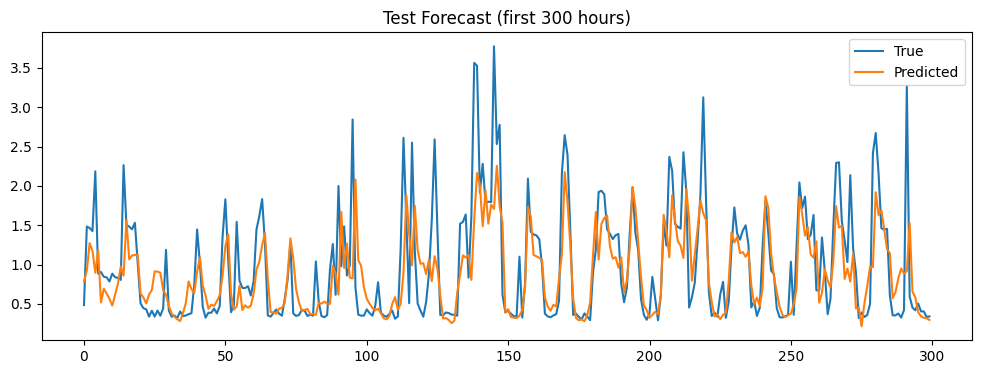

In [256]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(y_true[:300], label="True")
plt.plot(y_pred[:300], label="Predicted")
plt.legend()
plt.title("Test Forecast (first 300 hours)")
plt.show()


In [257]:
y_true.min(), np.quantile(y_true, 0.05)

(np.float64(0.1604375715922107), np.float64(0.28222333333333327))

In [258]:
smape = np.mean(
    2 * np.abs(y_true - y_pred)
    / (np.abs(y_true) + np.abs(y_pred) + 1e-6)
) * 100

mask = y_true > 0.5

masked_mape = np.mean(
    np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])
) * 100


In [259]:
(f"smape: {smape}", f"masked_mape: {masked_mape}")

('smape: 34.04118136336882', 'masked_mape: 31.117208898534027')

In [260]:
mask = y_true > 0.5

masked_mape = np.mean(
    np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])
) * 100

masked_mape


np.float64(31.117208898534027)